# Indoor generation and scene extension

Companion to `01_scene_completion_from_sensor_view.ipynb`, which conditions on a
partial observation. This one covers the two *unconditional* paths:

1. **Generation** — sample a scene from noise, structure first then semantics.
2. **Extension** — grow an existing scene along +x indefinitely, 64 voxels at a time.

Both run through the same `IndoorPipeline` the CLI uses, so what you see here is
what `octree-diff generate` and `octree-diff extend` produce.

In [1]:
import os, sys, glob, time

# run from the repo root regardless of where the notebook was launched
# (anchor on pyproject.toml -- main.py was removed when the CLI landed)
root = os.getcwd()
while not os.path.exists(os.path.join(root, "pyproject.toml")) and root != "/":
    root = os.path.dirname(root)
os.chdir(root)
sys.path.insert(0, root)
print("repo root:", root)

import torch, numpy as np, matplotlib.pyplot as plt

from octree_diff.inference.pipeline import (
    IndoorPipeline, split_big_to_octree, split_big_to_occupancy,
    labels_to_split_big, build_doctree, voxel_mask_to_latent_mask,
    voxel_mask_to_node_mask, GRID,
)
from octree_diff.viz.vis_indoor import (
    plot_3d, plot_slice, compare_row, legend_for, class_colors, label_name,
)

# NOTE: must come after the imports above -- octree_diff.octree.util_dualoctree
# calls matplotlib.use("Agg") at import time, which silently kills inline figures.
%matplotlib inline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEVICE)

repo root: <repo>


device: cuda


## 1. Load the models

Four checkpoints: a VAE and a diffusion model for structure (occupancy), and the
same pair again for semantics (per-voxel labels). The `latent_scale` values printed
below matter — the diffusion schedule assumes roughly unit-variance latents, so the
VAE latents are multiplied by this factor during training and **must be divided by
it again before decoding**. Getting this wrong produces plausible-looking noise.

In [2]:
pipe = IndoorPipeline(DEVICE)
print(f"latent scales:  structure {pipe.str_scale:.4f}   semantic {pipe.sem_scale:.4f}")
for k, v in pipe.paths.items():
    print(f"  {k:22s} {os.path.relpath(v, root)}")

latent scales:  structure 2.0029   semantic 3.0764
  structure_vae          saved_model/structure_vae.pt
  structure_diffusion    saved_model/structure_diffusion.pt
  semantic_vae           saved_model/vae_model_5.pt
  semantic_diffusion     saved_model/unet_sem_diffusion.pt


## 2. Unconditional generation

`sample_structure` draws a layout from noise in the structure VAE's latent space.
That layout becomes an octree, and `sample_semantics` then labels its occupied
nodes. The two stages are independent models — the second is conditioned only on
the geometry the first produced.

In [3]:
N_SAMPLES = 6
STEPS = 100

scenes, layouts = [], []
for i in range(N_SAMPLES):
    t0 = time.time()
    split_big = pipe.sample_structure(STEPS, eta=0.0)
    octree = split_big_to_octree(split_big, pipe.sem_full_depth)
    labels = pipe.sample_semantics(octree, STEPS, eta=0.0)
    scenes.append(labels.cpu())
    layouts.append(split_big_to_occupancy(split_big).cpu())
    occ = (labels > 0).float().mean().item()
    print(f"  sample {i}: {time.time()-t0:5.1f}s   occupied {occ:.3f}   "
          f"{len(labels.unique())} classes")

  loaded structure_diffusion from <repo>/saved_model/structure_diffusion.pt


  loaded structure_vae from <repo>/saved_model/structure_vae.pt
  loaded semantic_diffusion from <repo>/saved_model/unet_sem_diffusion.pt


  loaded semantic_vae from <repo>/saved_model/vae_model_5.pt
  sample 0:   4.0s   occupied 0.053   63 classes


<env:octree-nb>/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  sample 1:   4.1s   occupied 0.069   73 classes


  sample 2:   4.8s   occupied 0.087   72 classes


  sample 3:   3.5s   occupied 0.063   69 classes


  sample 4:   3.6s   occupied 0.067   72 classes


  sample 5:   4.5s   occupied 0.092   79 classes


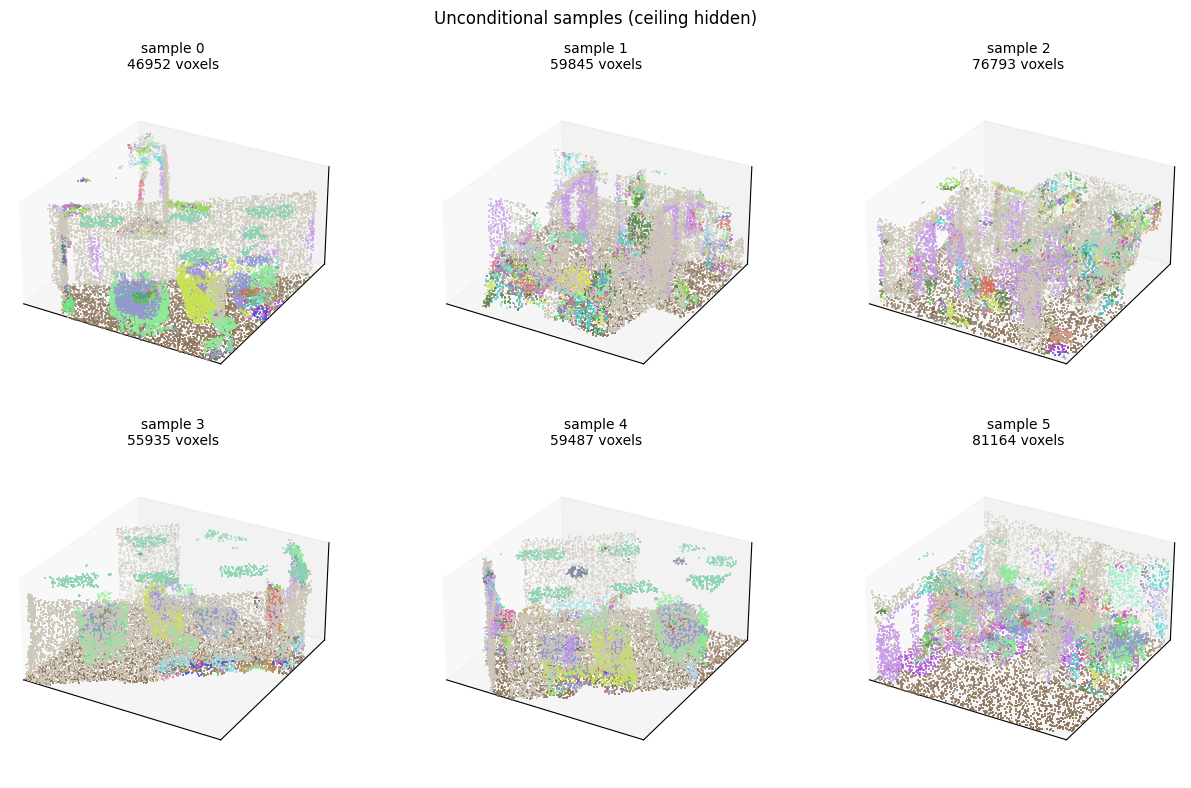

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw={"projection": "3d"})
for ax, s, i in zip(axes.ravel(), scenes, range(N_SAMPLES)):
    plot_3d(s, ax=ax, title=f"sample {i}")
fig.suptitle("Unconditional samples (ceiling hidden)", y=0.98)
fig.tight_layout(); plt.show()

## 3. One layout, several labellings

Because the stages are separate, a single structure can be re-labelled repeatedly.
This is a useful diagnostic: if the semantic model has collapsed, every draw comes
back with the same handful of classes regardless of the geometry underneath.

  seed 200: 74 classes, top-5 [2, 3, 1, 38, 30]


  seed 201: 87 classes, top-5 [2, 3, 1, 38, 30]


  seed 202: 85 classes, top-5 [2, 3, 1, 38, 30]


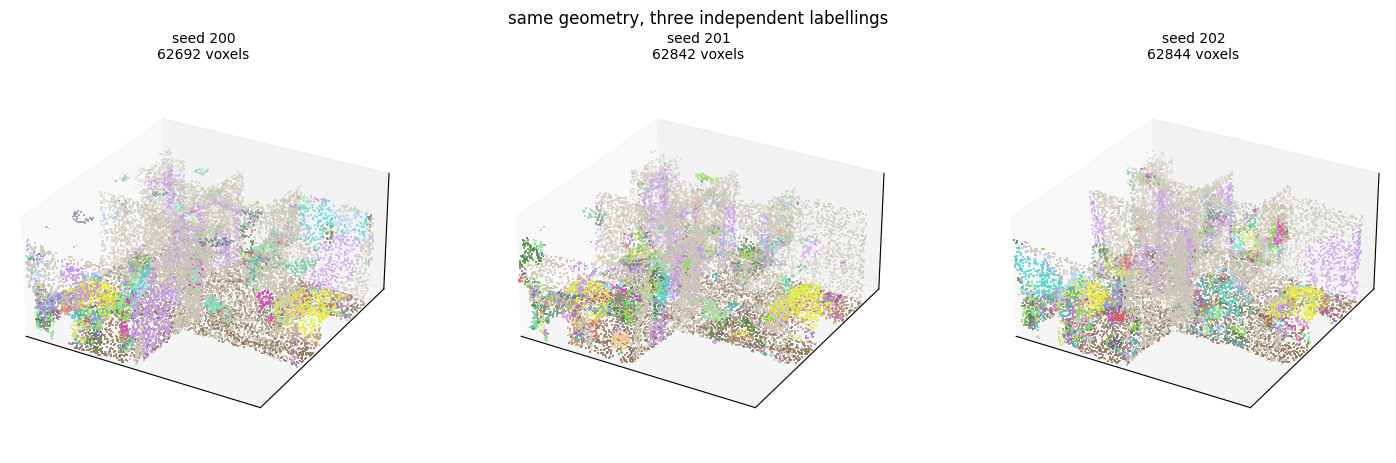

In [5]:
split_big = pipe.sample_structure(STEPS, eta=0.0)
octree = split_big_to_octree(split_big, pipe.sem_full_depth)

variants = []
for seed in range(3):
    torch.manual_seed(200 + seed)
    lab = pipe.sample_semantics(octree, STEPS, eta=0.0)
    variants.append(lab.cpu())
    print(f"  seed {200+seed}: {len(lab.unique())} classes, "
          f"top-5 {torch.bincount(lab.flatten().cpu(), minlength=92)[1:].argsort(descending=True)[:5].add(1).tolist()}")

fig = compare_row(variants, [f"seed {200+s}" for s in range(3)])
fig.suptitle("same geometry, three independent labellings", y=1.02)
plt.show()

## 4. Do generated scenes look like real ones?

Two cheap population-level checks against the held-out patches: what fraction of
the grid is occupied, and which classes dominate. These are the same numbers
`octree-diff verify` reports for the `generate` check.

In [6]:
real_files = sorted(glob.glob("data/patches_val/*.pt"))[:40]
real_occ, real_hist = [], torch.zeros(92)
for f in real_files:
    lab = torch.load(f, weights_only=False)["labels"].permute(1, 2, 0).long()
    real_occ.append((lab > 0).float().mean().item())
    real_hist += torch.bincount(lab.flatten(), minlength=92).float()

gen_occ = [(s > 0).float().mean().item() for s in scenes]
gen_hist = torch.zeros(92)
for s in scenes:
    gen_hist += torch.bincount(s.flatten(), minlength=92).float()

print(f"occupied fraction   generated {np.mean(gen_occ):.4f}   real {np.mean(real_occ):.4f}")
for name, h in (("generated", gen_hist), ("real", real_hist)):
    occ = h.clone(); occ[0] = 0
    top = occ.argsort(descending=True)[:5]
    print(f"  {name:10s} top-5: " + ", ".join(f"{label_name(int(i))}({int(i)})" for i in top))

occupied fraction   generated 0.0720   real 0.0644
  generated  top-5: wall(2), ceiling(3), floor(1), class 24(24), class 38(38)
  real       top-5: wall(2), ceiling(3), floor(1), class 38(38), class 24(24)


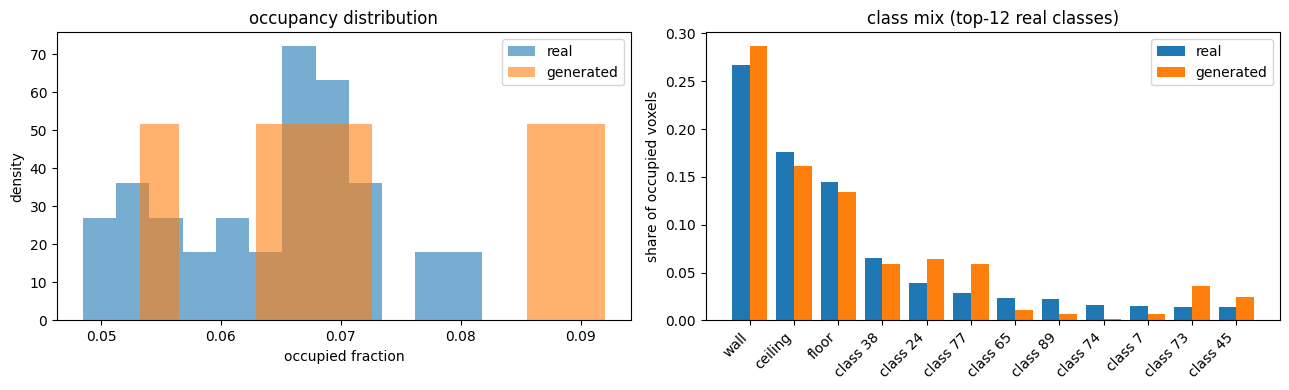

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(real_occ, bins=12, alpha=0.6, label="real", density=True)
axes[0].hist(gen_occ, bins=12, alpha=0.6, label="generated", density=True)
axes[0].set_xlabel("occupied fraction"); axes[0].set_ylabel("density")
axes[0].set_title("occupancy distribution"); axes[0].legend()

occ_r = real_hist.clone(); occ_r[0] = 0; occ_r /= occ_r.sum()
occ_g = gen_hist.clone(); occ_g[0] = 0; occ_g /= occ_g.sum()
top = occ_r.argsort(descending=True)[:12]
x = np.arange(len(top))
axes[1].bar(x - 0.2, occ_r[top], 0.4, label="real")
axes[1].bar(x + 0.2, occ_g[top], 0.4, label="generated")
axes[1].set_xticks(x); axes[1].set_xticklabels([label_name(int(i)) for i in top], rotation=45, ha="right")
axes[1].set_ylabel("share of occupied voxels"); axes[1].set_title("class mix (top-12 real classes)")
axes[1].legend()
fig.tight_layout(); plt.show()

## 5. Scene extension along +x

Extension is outpainting in a sliding window. Each step takes the trailing half of
the scene as the *known* region, leaves the leading half empty, and inpaints it —
structure first, then semantics — then appends the new half. Repeating this grows
the scene without bound while keeping every seam locally consistent.

`best_of` is worth setting above 1 here: roughly 1 draw in 20 degrades, and because
each step conditions on the previous one, a bad step corrupts everything after it.

In [8]:
SRC = sorted(glob.glob("data/patches_val/*.pt"))[3]
seed_scene = torch.load(SRC, weights_only=False)["labels"].permute(1, 2, 0).contiguous().long().to(DEVICE)

STEPS_OUT, BEST_OF = 4, 3
scene = seed_scene.clone()
half = GRID[0] // 2

for k in range(STEPS_OUT):
    t0 = time.time()
    window = torch.zeros(GRID, dtype=torch.long, device=DEVICE)
    window[:half] = scene[-half:]
    known = torch.zeros(GRID, dtype=torch.bool, device=DEVICE)
    known[:half] = True

    split_big = pipe.inpaint_structure(labels_to_split_big(window, DEVICE),
                                       voxel_mask_to_latent_mask(known),
                                       STEPS, 0.0, 1, BEST_OF)
    octree = split_big_to_octree(split_big, pipe.sem_full_depth)
    doctree = build_doctree(octree)
    node_mask = voxel_mask_to_node_mask(known, octree, doctree)
    out = pipe.inpaint_semantics(octree, window, node_mask, STEPS, 0.0, 1)

    scene = torch.cat([scene, out[half:]], dim=0)
    print(f"  step {k}: scene now {tuple(scene.shape)}  ({time.time()-t0:.1f}s)")

<env:octree-nb>/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  step 0: scene now (192, 128, 64)  (5.8s)


  step 1: scene now (256, 128, 64)  (5.3s)


  step 2: scene now (320, 128, 64)  (5.6s)


  step 3: scene now (384, 128, 64)  (5.6s)


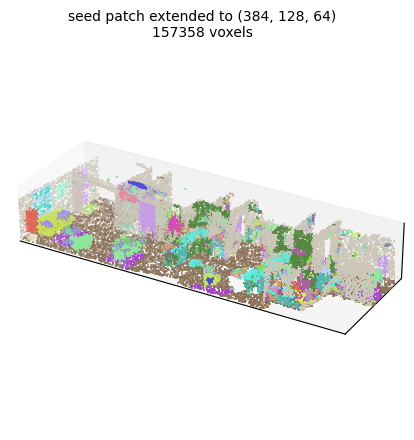

In [9]:
ext = scene.cpu()
fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(111, projection="3d")
plot_3d(ext, ax=ax, title=f"seed patch extended to {tuple(ext.shape)}", max_points=40000)
plt.show()

## 6. Seam quality

The honest check on extension: occupancy should not jump at the joins, and it
should not drift toward empty over successive steps. A monotone decline means the
model is losing the conditioning and generating into a vacuum.

occupied fraction per 64-voxel slab:
  0.064  0.071  0.068  0.059  0.080  0.051

across each seam (last slice before -> first slice after):
  x=  64:  0.059 -> 0.060
  x= 128:  0.060 -> 0.073
  x= 192:  0.037 -> 0.053
  x= 256:  0.036 -> 0.067
  x= 320:  0.029 -> 0.051


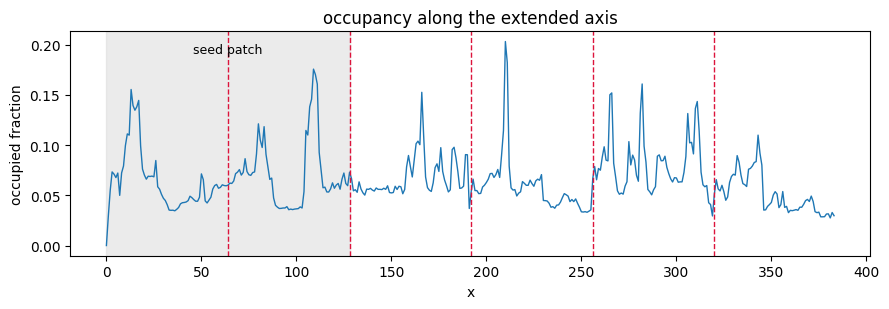

In [10]:
occ = (ext > 0)
per_step = [occ[i*half:(i+1)*half].float().mean().item()
            for i in range(occ.shape[0] // half)]
print("occupied fraction per 64-voxel slab:")
print("  " + "  ".join(f"{v:.3f}" for v in per_step))

print("\nacross each seam (last slice before -> first slice after):")
for k in range(1, occ.shape[0] // half):
    x = k * half
    print(f"  x={x:4d}:  {occ[x-1].float().mean():.3f} -> {occ[x].float().mean():.3f}")

fig, ax = plt.subplots(figsize=(9, 3.2))
prof = occ.float().mean(dim=(1, 2)).numpy()
ax.plot(prof, lw=1)
for k in range(1, occ.shape[0] // half):
    ax.axvline(k * half, color="crimson", ls="--", lw=1)
ax.axvspan(0, GRID[0], color="0.85", alpha=0.5)
ax.text(GRID[0] / 2, ax.get_ylim()[1] * 0.9, "seed patch", ha="center", fontsize=9)
ax.set_xlabel("x"); ax.set_ylabel("occupied fraction"); ax.set_title("occupancy along the extended axis")
fig.tight_layout(); plt.show()

## Notes

- **Latent scaling is not optional.** `pipe.str_scale` / `pipe.sem_scale` come from
  the `*_meta.yaml` sidecars written next to each diffusion checkpoint at training
  time. If a sidecar is missing, `load_latent_scale` silently returns `1.0` and
  everything still runs — producing over-scaled latents that decode to plausible
  rubbish. Ship the sidecars with the weights.

- **`best_of` guards extension, not just completion.** Errors compound across steps
  because each conditions on the last.

- The equivalent CLI invocations:

  ```bash
  octree-diff generate --num-samples 6 --steps 100 --out out/gen
  octree-diff extend --input scene.pt --steps-out 4 --best-of 3 --out out/ext
  ```